# Germany Solar PV Market Analysis
### Market intelligence for IP67 solar-enclosure export sales (Jalpa Plastic)

This notebook analyzes Germany's solar PV market — installed capacity growth, state-level
demand, and the ground-mount vs. rooftop split — to identify where demand for heavy-duty
**IP67 outdoor enclosures** is concentrated, and to prioritize follow-up with buyers met at
**Intersolar Munich 2026**.

**Data sources:** Bundesnetzagentur (German Federal Network Agency) and Fraunhofer ISE
(energy-charts.info). Full citations in `README.md`.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

NAVY, BLUE, ORANGE, LIGHT_BLUE = "#1F3864", "#2E75B6", "#ED7D31", "#9DC3E6"
plt.rcParams["font.family"] = "DejaVu Sans"

national = pd.read_csv("data/national_annual.csv")
states = pd.read_csv("data/state_data_2025.csv")
segments = pd.read_csv("data/segment_data.csv")

print(national.tail(6).to_string(index=False))


 year  annual_addition_gw  cumulative_installed_gw                   data_confidence                                                     source
 2021                5.30                      NaN    Approx (widely-cited estimate)     Industry estimates (BSW-Solar / IEA historical series)
 2022                7.50                      NaN    Approx (widely-cited estimate)     Industry estimates (BSW-Solar / IEA historical series)
 2023               14.40                    81.70                         Confirmed                         Bundesnetzagentur / Fraunhofer ISE
 2024               16.73                    98.43                         Confirmed              Bundesnetzagentur (via Taiyang News citation)
 2025               16.40                   117.00        Confirmed (BNetzA prelim.)                Bundesnetzagentur press release, 8 Jan 2026
 2026                7.00                   124.90 Confirmed (H1 only, partial year) Fraunhofer ISE / PV Tech, H1 2026 data (as of 30 Ju

## 1. Cumulative installed capacity is accelerating sharply since 2023

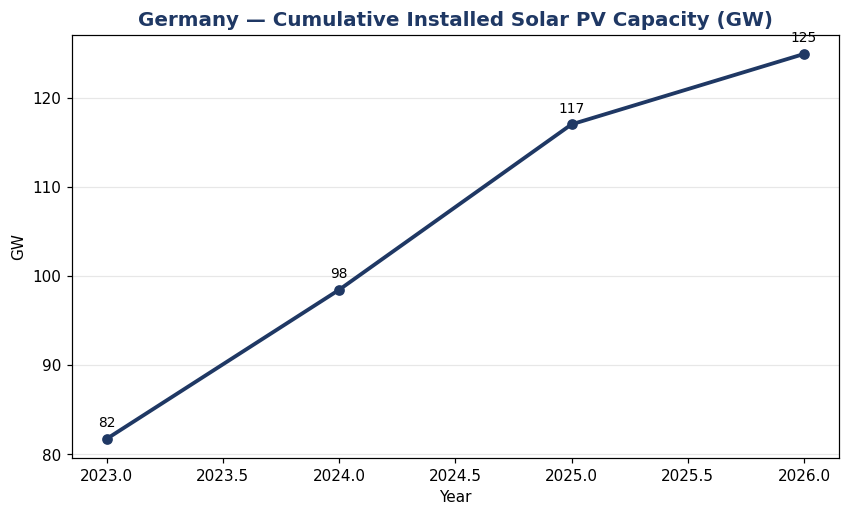

In [4]:
df = national.dropna(subset=["cumulative_installed_gw"])
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(df["year"], df["cumulative_installed_gw"], marker="o", color=NAVY, linewidth=2.5)
ax.set_title("Germany — Cumulative Installed Solar PV Capacity (GW)", fontsize=13, fontweight="bold", color=NAVY)
ax.set_xlabel("Year"); ax.set_ylabel("GW"); ax.grid(axis="y", alpha=0.3)
for x, y in zip(df["year"], df["cumulative_installed_gw"]):
    ax.annotate(f"{y:.0f}", (x, y), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
plt.show()


**Reading:** Germany crossed 100 GW of installed solar capacity in early 2025 and reached
~125 GW by mid-2026 — up from 81.7 GW at the end of 2023. That's roughly 50% growth in under
three years.

## 2. Annual additions are far below the pace needed for the 2030 target

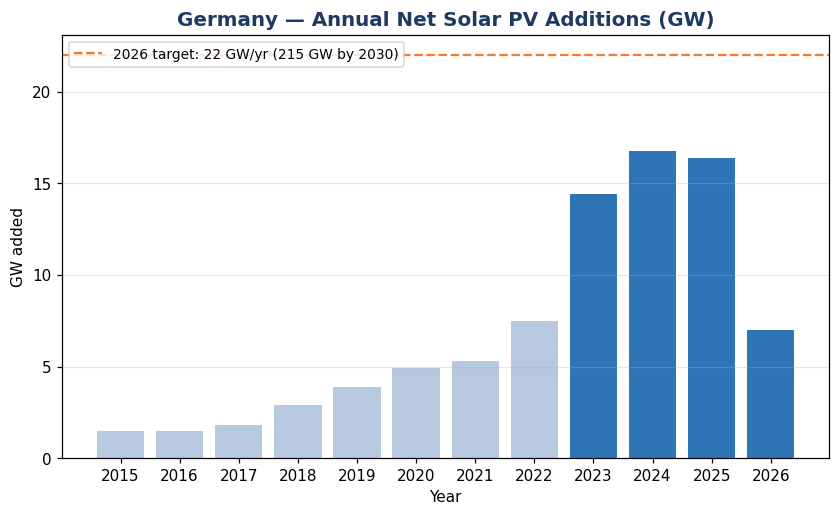

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = [BLUE if str(c).startswith("Confirmed") else "#B7C9DE" for c in national["data_confidence"]]
ax.bar(national["year"].astype(str), national["annual_addition_gw"], color=colors)
ax.set_title("Germany — Annual Net Solar PV Additions (GW)", fontsize=13, fontweight="bold", color=NAVY)
ax.set_xlabel("Year"); ax.set_ylabel("GW added")
ax.axhline(22, color=ORANGE, linestyle="--", linewidth=1.5, label="2026 target: 22 GW/yr (215 GW by 2030)")
ax.legend(loc="upper left", fontsize=9); ax.grid(axis="y", alpha=0.3)
plt.show()


**Reading:** 2025's 16.4 GW addition was actually *slightly below* 2024's pace, and both fall
well short of the ~22 GW/year Germany needs to hit its 215 GW-by-2030 target. That gap is a
structural tailwind for suppliers: buyers and EPCs are under pressure to scale procurement fast,
which supports urgency in sales outreach. *(Lighter bars = pre-2023 figures reconstructed from
public industry commentary rather than a single official table — see README for confidence notes.)*

## 3. Bavaria, Baden-Württemberg and NRW dominate state-level demand

Top 3 states = 51.6% of all state-attributed 2025 additions


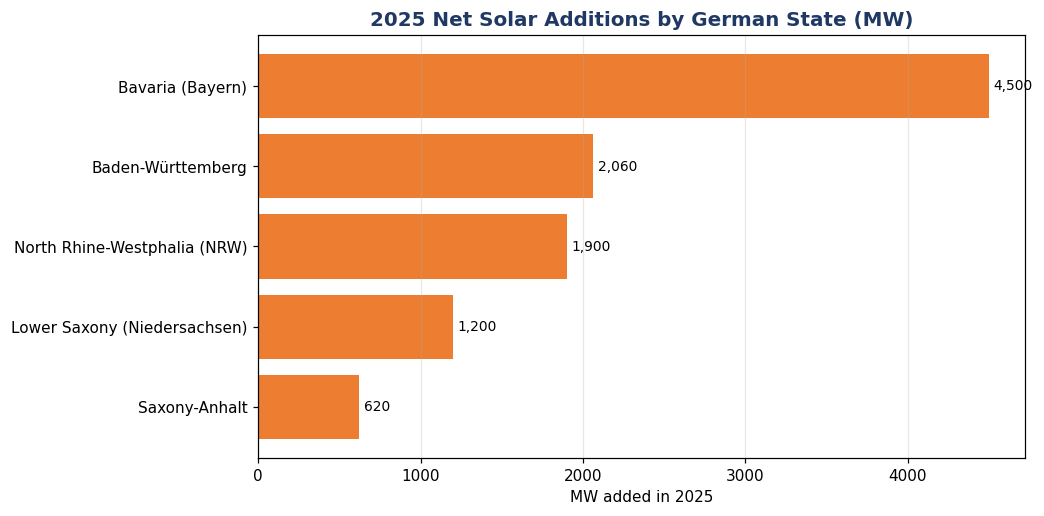

In [10]:
df = states[states["rank_2025"].notna()].sort_values("addition_2025_mw", ascending=True)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(df["state"], df["addition_2025_mw"], color=ORANGE)
ax.set_title("2025 Net Solar Additions by German State (MW)", fontsize=13, fontweight="bold", color=NAVY)
ax.set_xlabel("MW added in 2025")
for y, val in enumerate(df["addition_2025_mw"]):
    ax.text(val + 30, y, f"{val:,.0f}", va="center", fontsize=9)
ax.grid(axis="x", alpha=0.3)
plt.show()

top3_share = states.iloc[0:3]["addition_2025_mw"].sum() / states["addition_2025_mw"].sum()
print(f"Top 3 states = {top3_share:.1%} of all state-attributed 2025 additions")


## 4. Ground-mount share is rising — the segment that needs heavy-duty IP67 enclosures most

          period  ground_mount_share
2024 (full year)            0.333533
2025 (full year)            0.335366
         H1 2026            0.522388


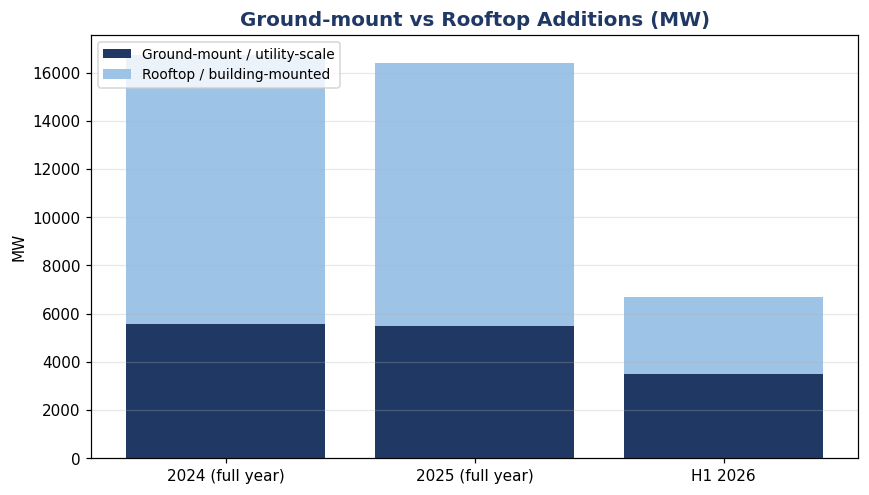

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
x = segments["period"]
ax.bar(x, segments["ground_mount_mw"], label="Ground-mount / utility-scale", color=NAVY)
ax.bar(x, segments["rooftop_building_mw"], bottom=segments["ground_mount_mw"],
       label="Rooftop / building-mounted", color=LIGHT_BLUE)
ax.set_title("Ground-mount vs Rooftop Additions (MW)", fontsize=13, fontweight="bold", color=NAVY)
ax.set_ylabel("MW"); ax.legend(loc="upper left", fontsize=9); ax.grid(axis="y", alpha=0.3)
plt.show()

print(segments[["period", "ground_mount_share"]].to_string(index=False))


**Reading:** Ground-mount / utility-scale solar — which typically requires more, and heavier-duty,
IP67 combiner and junction enclosures than residential rooftop — grew from ~33% of additions in
2024-2025 to **over 50% in H1 2026**. That's a concrete, data-backed reason to prioritize outreach
to utility-scale EPCs and solar-park developers, not just rooftop installers.

## Key findings summary

1. Germany's installed solar capacity reached **117 GW at end-2025**, growing to **~125 GW by
   mid-2026** — up ~50% since end-2023.
2. Annual additions (**16.4 GW in 2025**) are running below the **~22 GW/year** pace needed for
   Germany's 215 GW-by-2030 target — a supply-side gap that creates urgency for buyers to lock in
   suppliers.
3. **Bavaria, Baden-Württemberg, and NRW** together account for **~52%** of all state-attributed
   2025 additions — the clear priority states for enclosure sales outreach.
4. The **ground-mount/utility-scale segment — the highest-value segment for IP67 enclosures — grew
   from ~33% to over 50%** of new capacity between 2024 and H1 2026.

## How to reproduce
```bash
pip install -r requirements.txt
python3 analysis.py       # regenerates charts/ as PNGs
# or open this notebook directly — all outputs are already saved/committed
```

Data sources and full methodology: see `README.md`.
